<a href="https://colab.research.google.com/github/srirambandi/ai/blob/master/experiments/gan_latent_space_splicing_expriment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/srirambandi/ai.git
%cd ai

Cloning into 'ai'...
remote: Enumerating objects: 906, done.
remote: Counting objects: 100% (210/210), done.
remote: Compressing objects: 100% (161/161), done.
remote: Total 906 (delta 137), reused 100 (delta 49), pack-reused 696 (from 1)
Receiving objects: 100% (906/906), 188.91 MiB | 41.26 MiB/s, done.
Resolving deltas: 100% (600/600), done.
Updating files: 100% (42/42), done.
/content/ai


In [ ]:
# !rm -rf ../ai/

In [2]:
import os
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/ai/experiments"
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


In [3]:
import ai
import numpy as np

In [4]:
z_dim = 2
gf_dim = 64
df_dim = 64

In [5]:
ai.manual_seed(2357)

In [6]:
def data_generator(m):
    train_dict = np.load('examples/MNIST/train.npy', allow_pickle=True)
    test_dict = np.load('examples/MNIST/test.npy', allow_pickle=True)
    data = np.concatenate([train_dict.item()['data'], test_dict.item()['data']])
    # data = data.transpose(1, 2, 0)   # making data batch-last
    data = np.expand_dims(data, axis=1) / 127.5 - 1.   # adding channel dimension and normalizing data
    epoch = 0

    while True:
        epoch += 1
        for batch in range(int(data.shape[0] / m)):
            yield data[batch * m:(batch + 1) * m, ...], epoch

In [7]:
class Generator(ai.Module):
    def __init__(self):
        self.g_fc = ai.Linear(z_dim, 8*gf_dim * 2 * 2)
        self.g_bn1 = ai.BatchNorm2d(8*gf_dim)
        self.g_deconv1 = ai.ConvTranspose2d(8*gf_dim, 4*gf_dim, 5, stride=2, padding=2, output_padding=1)
        self.g_bn2 = ai.BatchNorm2d(4*gf_dim)
        self.g_deconv2 = ai.ConvTranspose2d(4*gf_dim, 2*gf_dim, 5, stride=2, padding=2, output_padding=0)
        self.g_bn3 = ai.BatchNorm2d(2*gf_dim)
        self.g_deconv3 = ai.ConvTranspose2d(2*gf_dim, gf_dim, 5, stride=2, padding=2, output_padding=1)
        self.g_bn4 = ai.BatchNorm2d(gf_dim)
        self.g_deconv4 = ai.ConvTranspose2d(gf_dim, 1, 5, stride=2, padding=2, output_padding=1)

    def forward(self, z):
        o1 = ai.G.reshape(self.g_fc(z), (8*gf_dim, 2, 2))
        o2 = ai.G.relu(self.g_bn1(o1))
        o3 = ai.G.relu(self.g_bn2(self.g_deconv1(o2)))
        o4 = ai.G.relu(self.g_bn3(self.g_deconv2(o3)))
        o5 = ai.G.relu(self.g_bn4(self.g_deconv3(o4)))
        fake_image = ai.G.tanh(self.g_deconv4(o5))
        return fake_image

In [8]:
class Discriminator(ai.Module):
    def __init__(self):
        self.d_conv1 = ai.Conv2d(1, 64, 5, stride=2, padding=2)
        self.d_conv2 = ai.Conv2d(64, 2*64, 5, stride=2, padding=2)
        self.d_bn1 = ai.BatchNorm2d(2*64)
        self.d_conv3 = ai.Conv2d(2*64, 3*64, 5, stride=2, padding=2)
        self.d_bn2 = ai.BatchNorm2d(3*64)
        self.d_conv4 = ai.Conv2d(3*64, 4*64, 5, stride=2, padding=2)
        self.d_bn3 = ai.BatchNorm2d(4*64)
        self.d_fc = ai.Linear(1024, 1)

    def forward(self, image):
        o1 = ai.G.lrelu(self.d_conv1(image))
        o2 = ai.G.lrelu(self.d_bn1(self.d_conv2(o1)))
        o3 = ai.G.lrelu(self.d_bn2(self.d_conv3(o2)))
        o4 = ai.G.lrelu(self.d_bn3(self.d_conv4(o3)))
        o5 = self.d_fc(o4)
        return ai.G.sigmoid(o5)

In [9]:
generator = Generator()
discriminator = Discriminator()
print(generator)
print(discriminator)

Generator(
  g_fc: Linear(in_features=2, out_features=2048, bias=True)
  g_bn1: BatchNorm2d(num_channels=512, eps=1e-05, momentum=0.1)
  g_deconv1: ConvTranspose2d(in_channels=512, out_channels=256,
 	kernel_size=(5, 5),                stride=(2, 2)
, 	padding=(2, 2), output_padding=(1, 1), bias=True)
  g_bn2: BatchNorm2d(num_channels=256, eps=1e-05, momentum=0.1)
  g_deconv2: ConvTranspose2d(in_channels=256, out_channels=128,
 	kernel_size=(5, 5),                stride=(2, 2)
, 	padding=(2, 2), output_padding=(0, 0), bias=True)
  g_bn3: BatchNorm2d(num_channels=128, eps=1e-05, momentum=0.1)
  g_deconv3: ConvTranspose2d(in_channels=128, out_channels=64,
 	kernel_size=(5, 5),                stride=(2, 2)
, 	padding=(2, 2), output_padding=(1, 1), bias=True)
  g_bn4: BatchNorm2d(num_channels=64, eps=1e-05, momentum=0.1)
  g_deconv4: ConvTranspose2d(in_channels=64, out_channels=1,
 	kernel_size=(5, 5),                stride=(2, 2)
, 	padding=(2, 2), output_padding=(1, 1), bias=True)
)
Disc

In [10]:
lr = 0.0002
beta1 = 0.5
L = ai.Loss(loss_fn='BCELoss')
g_optim = ai.Optimizer(generator.parameters(), optim_fn='Adam', lr=lr, beta1=beta1)
d_optim = ai.Optimizer(discriminator.parameters(), optim_fn='Adam', lr=lr, beta1=beta1)

In [11]:
it, epoch = 0, 0
m = 64   # batch size
n_discriminator = 1   # number of descriminator updates per generator update

# real images data generator
data = data_generator(m)

sample_z = np.random.uniform(-1, 1, (m, z_dim))
sampled_images = None

In [12]:
def sampler(sampled_images):
    ai.G.grad_mode = False

    # generate images like real data
    fake_images = generator.forward(sample_z).data
    fake_images = (fake_images + 1.) / 2.

    if sampled_images is not None:
        sampled_images = np.concatenate([sampled_images, fake_images], axis=0)
    else:
        sampled_images = fake_images

    ai.G.grad_mode = True

    return sampled_images

In [14]:
for it in range(6000):

    # freeze generator before optimizing descriminator
    for p in generator.parameters():
        p.eval_grad = False

    # training descriminator to identify real/fake data
    for _ in range(n_discriminator):

        real_images, epoch = next(data)
        real_labels = np.ones((m, 1))
        if (real_images.shape[0] != m):
            continue

        print(f"inside descriminator train loop {epoch}")

        real_probs = discriminator.forward(real_images)
        d_loss_real = L.loss(real_probs, real_labels)

        z = np.random.randn(m, z_dim)
        fake_images = generator.forward(z)
        fake_labels =  np.zeros((m, 1))

        fake_probs = discriminator.forward(fake_images)
        d_loss_fake = L.loss(fake_probs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.grad = np.zeros(d_loss.shape)

        d_loss.backward()
        d_optim.step()
        d_optim.zero_grad()

    # unfreeze generator
    for p in generator.parameters():
        p.eval_grad = True

    print(f"inside main train loop {it}")

    # training generator to fool descriminator with fake data
    z = np.random.uniform(-1, 1, (m, z_dim))
    fake_images = generator.forward(z)
    fake_labels =  np.ones((m, 1))

    fake_probs = discriminator.forward(fake_images)
    g_loss = L.loss(fake_probs, fake_labels)

    g_loss.backward()
    g_optim.step()
    g_optim.zero_grad()
    d_optim.zero_grad()

    if it%10 == 0:
        print(f'Iter: {it}, Epoch: {epoch}, d_loss: {d_loss.data[0, 0]}, g_loss: {g_loss.data[0, 0]}')

    if it%100 == 0:
        sampled_images=sampler(sampled_images)
        np.save(f'{SAVE_DIR}/GAN/sampled_images.npy', sampled_images)
        generator.save(f'{SAVE_DIR}/GAN/Generator.npy')
        discriminator.save(f'{SAVE_DIR}/GAN/Discriminator.npy')

inside descriminator train loop 1


ValueError: mismatch in length of strides and shape

In [13]:
import imageio

def save_images(sampled_images):

    # Check and convert the range of the images
    if sampled_images.max() <= 1.0:
        sampled_images = (sampled_images * 255).astype(np.uint8)

    grids = []
    h, w = int(np.sqrt(m)), int(np.sqrt(m))
    for i in range(int(sampled_images.shape[0]/m)):
        grid = []
        batch = sampled_images[i*m:(i+1)*m, ...]

        for r in range(h):
            row = np.squeeze(batch[r*w, ...])

            for c in range(1, w):
                row = np.concatenate([row, np.squeeze(batch[r*w + c, ...])], axis=1)

            grid.append(row)

        grid = np.concatenate(grid, axis=0)
        grids.append(grid)

    imageio.mimsave(f'{SAVE_DIR}/GAN/gan.gif', grids)

sampled_images = np.load(f'{SAVE_DIR}/GAN/sampled_images.npy')
save_images(sampled_images)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ai/experiments/GAN/sampled_images.npy'

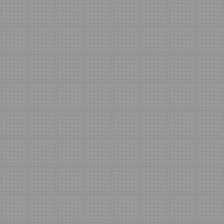

In [ ]:
from IPython.display import Image

with open(f'{SAVE_DIR}/GAN/gan.gif','rb') as f:
    display(Image(data=f.read(), format='png'))

In [ ]:
from IPython.display import SVG, display

def display_svg(filename):
    with open(f"assets/{filename}.svg", 'r') as file:
        svg = file.read()
        display(SVG(svg))

ai.draw_graph(filename='gan')
display_svg('gan')